<a href="https://colab.research.google.com/github/Anand-Kamal/SCT_ML_4/blob/main/hand_gesture_recognition_cnn_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hand Gesture Recognition (LeapGestRecog) with a Residual CNN

**Goal:** classify 10 hand gestures from images so they can drive a gesture-based control system.

**Design choices**
- **Grayscale, 1-channel input.** The dataset is infrared (Leap Motion) so colour carries no information. This cuts memory and training time.
- **Subject-disjoint train / validation / test.** Whole people are held out for validation *and* test, so the validation curve is honest (a random validation split leaks near-identical frames, which is why validation accuracy hits ~100% too early).
- **`tf.data` pipeline** with augmentation layers built into the model (active only during training).
- **Small residual CNN** built with the Functional API.
- Optional experiments (leakage demo, subject-wise cross-validation) behind switches so the default run is fast.

## 1. Setup

In [1]:
import os, random, time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)

IMG_SIZE   = 64
BATCH_SIZE = 64
EPOCHS     = 25

RUN_LEAKAGE_DEMO = False   # trains an extra model on a random split (slower)
RUN_GROUP_CV     = False   # subject-wise cross-validation (slowest)

print("TensorFlow:", tf.__version__, "| GPU:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0 | GPU: True


## 2. Download the dataset

In [2]:
root = kagglehub.dataset_download("gti-upm/leapgestrecog")
DATA_DIR = os.path.join(root, "leapGestRecog")
print("Dataset at:", DATA_DIR)

100%|██████████| 2.13G/2.13G [00:58<00:00, 39.2MB/s]

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapGestRecog


## 3. Index the files
Instead of loading images straight away, first build a table of *(path, label, subject)*. This makes the split logic and any later inspection simple.

In [3]:
subjects = sorted(os.listdir(DATA_DIR))
class_names = sorted(os.listdir(os.path.join(DATA_DIR, subjects[0])))
class_to_id = {name: i for i, name in enumerate(class_names)}
NUM_CLASSES = len(class_names)

rows = []
for subj in subjects:
    for cname in class_names:
        folder = os.path.join(DATA_DIR, subj, cname)
        for fname in os.listdir(folder):
            rows.append((os.path.join(folder, fname), class_to_id[cname], subj))

index = pd.DataFrame(rows, columns=["path", "label", "subject"])
print("Subjects   :", subjects)
print("Classes    :", class_to_id)
print("Total files:", len(index))

# Frames per subject x gesture (should be balanced)
index.pivot_table(index="subject", columns="label", values="path", aggfunc="count")

Subjects   : ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
Classes    : {'01_palm': 0, '02_l': 1, '03_fist': 2, '04_fist_moved': 3, '05_thumb': 4, '06_index': 5, '07_ok': 6, '08_palm_moved': 7, '09_c': 8, '10_down': 9}
Total files: 20000


label,0,1,2,3,4,5,6,7,8,9
subject,,,,,,,,,,
00,200,200,200,200,200,200,200,200,200,200
01,200,200,200,200,200,200,200,200,200,200
02,200,200,200,200,200,200,200,200,200,200
03,200,200,200,200,200,200,200,200,200,200
04,200,200,200,200,200,200,200,200,200,200
05,200,200,200,200,200,200,200,200,200,200
06,200,200,200,200,200,200,200,200,200,200
07,200,200,200,200,200,200,200,200,200,200
08,200,200,200,200,200,200,200,200,200,200


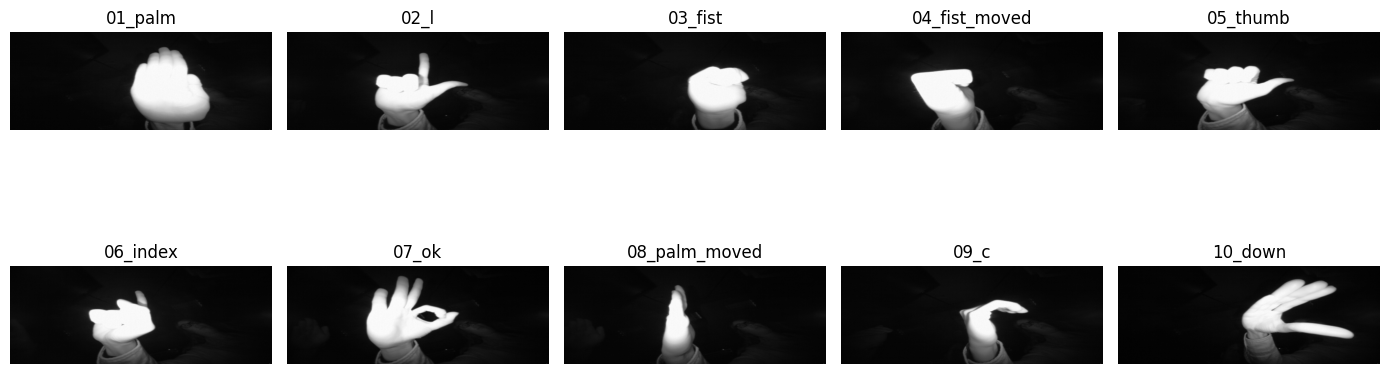

In [4]:
# Look at one example of every gesture before touching the data
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, (cid, cname) in zip(axes.ravel(), enumerate(class_names)):
    p = index[(index.label == cid) & (index.subject == subjects[0])].path.iloc[0]
    ax.imshow(cv2.imread(p, cv2.IMREAD_GRAYSCALE), cmap="gray")
    ax.set_title(cname); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Load images (grayscale, stored as `uint8`)

In [5]:
def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

t0 = time.time()
loaded = [load_gray(p) for p in index.path]
ok = np.array([im is not None for im in loaded])
if not ok.all():
    print(f"Dropping {(~ok).sum()} unreadable files")
index = index[ok].reset_index(drop=True)

X = np.stack([im for im in loaded if im is not None])[..., None]   # (N, 64, 64, 1) uint8
y = index.label.to_numpy()
groups = index.subject.to_numpy()
del loaded

print(f"X: {X.shape} {X.dtype} | {X.nbytes/1e6:.0f} MB | loaded in {time.time()-t0:.0f}s")

X: (20000, 64, 64, 1) uint8 | 82 MB | loaded in 40s


## 5. Subject-disjoint split
10 people are split into **6 train / 2 validation / 2 test**. No person appears in more than one set.

In [6]:
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(subjects)
train_subj, val_subj, test_subj = shuffled[:6], shuffled[6:8], shuffled[8:]

def take(subs):
    m = np.isin(groups, subs)
    return X[m], y[m]

X_train, y_train = take(train_subj)
X_val,   y_val   = take(val_subj)
X_test,  y_test  = take(test_subj)

print("Train subjects:", sorted(train_subj), X_train.shape[0], "frames")
print("Val subjects  :", sorted(val_subj),   X_val.shape[0],   "frames")
print("Test subjects :", sorted(test_subj),  X_test.shape[0],  "frames")

Train subjects: [np.str_('00'), np.str_('02'), np.str_('03'), np.str_('05'), np.str_('06'), np.str_('07')] 12000 frames
Val subjects  : [np.str_('04'), np.str_('09')] 4000 frames
Test subjects : [np.str_('01'), np.str_('08')] 4000 frames


## 6. `tf.data` pipelines

In [7]:
def make_ds(images, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((images, tf.one_hot(labels, NUM_CLASSES)))
    if training:
        ds = ds.shuffle(len(images), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val,   training=False)
test_ds  = make_ds(X_test,  y_test,  training=False)

## 7. Model
Three residual stages (32 → 64 → 128 filters). Rescaling and augmentation are part of the model, so raw `uint8` images go in and the pixel scale can never get out of sync with training.

In [8]:
def conv_bn_relu(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.ReLU()(x)

def residual_stage(x, filters, drop):
    skip = layers.Conv2D(filters, 1, padding="same")(x)      # match channel count
    h = conv_bn_relu(x, filters)
    h = conv_bn_relu(h, filters)
    x = layers.Add()([skip, h])
    x = layers.MaxPooling2D()(x)
    return layers.SpatialDropout2D(drop)(x)

augment = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.05),
], name="augment")

def build_model():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Rescaling(1.0 / 255)(inp)
    x = augment(x)                                   # only active during training
    for filters, drop in [(32, 0.10), (64, 0.15), (128, 0.20)]:
        x = residual_stage(x, filters, drop)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inp, out, name="gesture_resnet")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"],
    )
    return model

model = build_model()
model.summary()

Model: "gesture_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 1) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augment             │ (None, 64, 64, 1) │          0 │ rescaling[0][0]   │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │        288 │ augment[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │         64 │ augment[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d[0][0],     │
│                     │ 32)               │            │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,432 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,864 │ re_lu_2[0][0]   

 Total params: 316,074 (1.21 MB)

 Trainable params: 315,178 (1.20 MB)

 Non-trainable params: 896 (3.50 KB)

## 8. Train

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.5611 - loss: 1.4016 - val_accuracy: 0.1000 - val_loss: 5.3946 - learning_rate: 0.0010
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9679 - loss: 0.4864 - val_accuracy: 0.1975 - val_loss: 2.3758 - learning_rate: 0.0010
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9926 - loss: 0.3874 - val_accuracy: 0.9660 - val_loss: 0.7007 - learning_rate: 0.0010
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9957 - loss: 0.3591 - val_accuracy: 0.9275 - val_loss: 0.5506 - learning_rate: 0.0010
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9972 - loss: 0.3484 - val_accuracy: 1.0000 - val_loss: 0.3460 - learning_rate: 0.0010
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9980 - loss: 0.3377 - val_accuracy: 0.9983 - val_loss: 0.3406 - learning_rate: 0.0010
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9990 - l

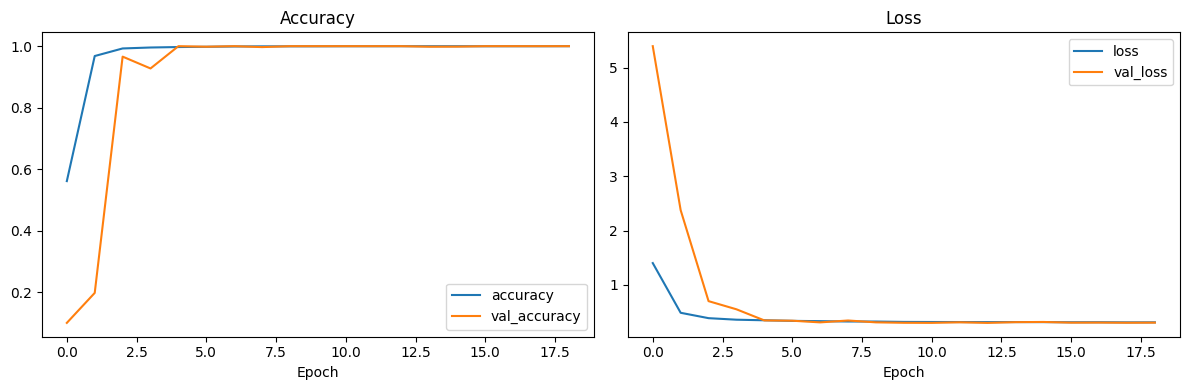

In [10]:
hist = pd.DataFrame(history.history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
hist[["accuracy", "val_accuracy"]].plot(ax=ax[0], title="Accuracy", xlabel="Epoch")
hist[["loss", "val_loss"]].plot(ax=ax[1], title="Loss", xlabel="Epoch")
plt.tight_layout(); plt.show()

## 9. Evaluate on unseen people (test subjects)
This is the number that reflects real-world use: a brand-new user.

In [11]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy on unseen subjects: {test_acc:.4f}")

probs = model.predict(test_ds, verbose=0)
pred = probs.argmax(axis=1)

print()
print(classification_report(y_test, pred, target_names=class_names, digits=3))

Test accuracy on unseen subjects: 0.9585

               precision    recall  f1-score   support

      01_palm      0.876     0.865     0.870       400
         02_l      1.000     0.927     0.962       400
      03_fist      0.982     0.825     0.897       400
04_fist_moved      1.000     0.968     0.983       400
     05_thumb      0.935     1.000     0.966       400
     06_index      1.000     1.000     1.000       400
        07_ok      0.990     1.000     0.995       400
08_palm_moved      0.883     1.000     0.938       400
         09_c      0.939     1.000     0.969       400
      10_down      1.000     1.000     1.000       400

     accuracy                          0.959      4000
    macro avg      0.960     0.959     0.958      4000
 weighted avg      0.960     0.959     0.958      4000



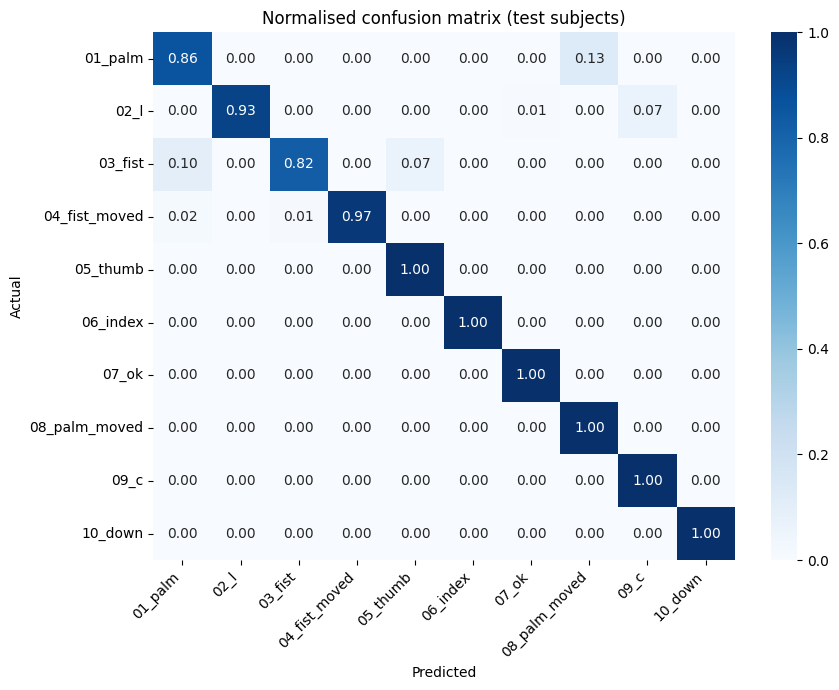

In [12]:
cm = confusion_matrix(y_test, pred, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Normalised confusion matrix (test subjects)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

166 of 4000 test frames misclassified


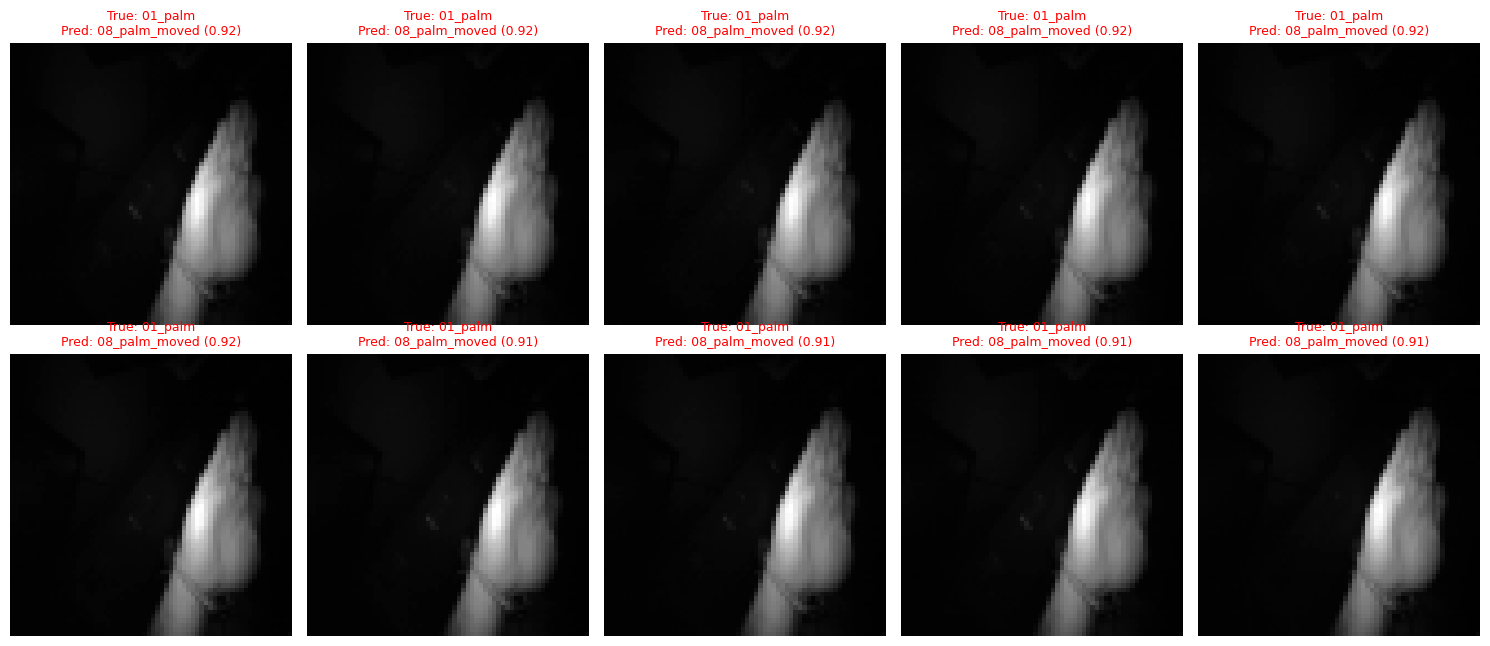

In [13]:
# Where does the model go wrong? Show its most confident mistakes.
wrong = np.where(pred != y_test)[0]
print(f"{len(wrong)} of {len(y_test)} test frames misclassified")

if len(wrong):
    worst = wrong[np.argsort(-probs[wrong].max(axis=1))][:10]
    fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
    for ax, i in zip(axes.ravel(), worst):
        ax.imshow(X_test[i, ..., 0], cmap="gray")
        ax.set_title(f"True: {class_names[y_test[i]]}\nPred: {class_names[pred[i]]} ({probs[i].max():.2f})",
                     color="red", fontsize=9)
        ax.axis("off")
    plt.tight_layout(); plt.show()

### Sample predictions (correct = green, wrong = red)
A random selection of test frames with the true label, the predicted label and the model's confidence.

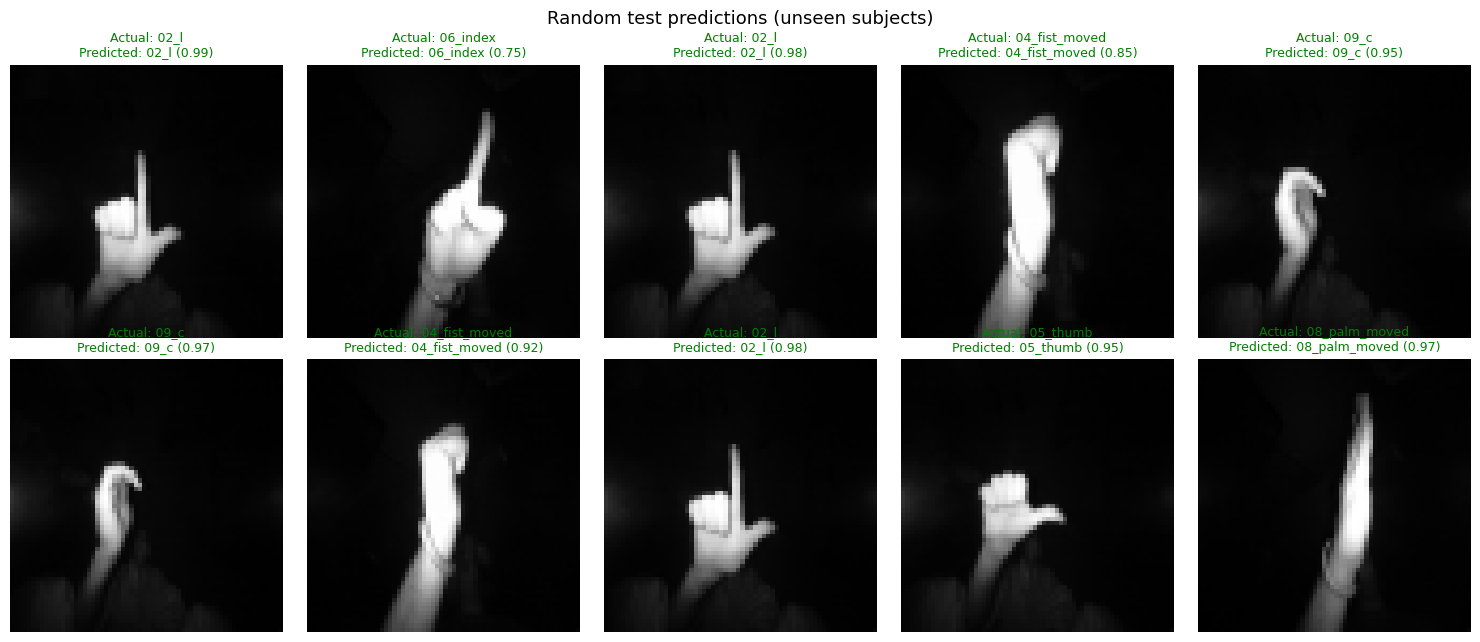

In [14]:
sample_idx = np.random.default_rng(SEED).choice(len(y_test), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for ax, i in zip(axes.ravel(), sample_idx):
    is_correct = pred[i] == y_test[i]
    ax.imshow(X_test[i, ..., 0], cmap="gray")
    ax.set_title(f"Actual: {class_names[y_test[i]]}\nPredicted: {class_names[pred[i]]} ({probs[i].max():.2f})",
                 color="green" if is_correct else "red", fontsize=9)
    ax.axis("off")
plt.suptitle("Random test predictions (unseen subjects)", fontsize=13)
plt.tight_layout(); plt.show()

## 10. (Optional) Why the subject-wise split matters
Trains a second model on an ordinary random split, where near-identical frames of the same person land in both train and test. Enable with `RUN_LEAKAGE_DEMO = True` at the top.

In [15]:
if RUN_LEAKAGE_DEMO:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    Xtr, Xva, ytr, yva = train_test_split(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=SEED)

    leaky = build_model()
    leaky.fit(make_ds(Xtr, ytr, True), validation_data=make_ds(Xva, yva, False),
              epochs=10, verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])
    _, leaky_acc = leaky.evaluate(make_ds(Xte, yte, False), verbose=0)

    print(f"Random split (leaky)        : {leaky_acc:.4f}")
    print(f"Subject-wise split (honest) : {test_acc:.4f}")
    print(f"Inflation from leakage      : {leaky_acc - test_acc:+.4f}")
else:
    print("Skipped (set RUN_LEAKAGE_DEMO = True to run).")

Skipped (set RUN_LEAKAGE_DEMO = True to run).


## 11. (Optional) Subject-wise cross-validation
Every fold holds out entire people. Enable with `RUN_GROUP_CV = True`.

In [16]:
if RUN_GROUP_CV:
    fold_scores = []
    for k, (tr, te) in enumerate(GroupKFold(n_splits=3).split(X, y, groups), start=1):
        m = build_model()
        m.fit(make_ds(X[tr], y[tr], True), epochs=10, verbose=0)
        _, a = m.evaluate(make_ds(X[te], y[te], False), verbose=0)
        fold_scores.append(a)
        print(f"Fold {k}: {a:.4f}  (held-out subjects: {sorted(set(groups[te]))})")
    print(f"\nMean = {np.mean(fold_scores):.4f} | Std = {np.std(fold_scores):.4f}")
else:
    print("Skipped (set RUN_GROUP_CV = True to run).")

Skipped (set RUN_GROUP_CV = True to run).


## 12. Save the model & classify a new image

In [17]:
model.save("gesture_model.keras")
print("Saved gesture_model.keras (download it from the Colab file browser)")

def predict_gesture(image_path, top_k=3):
    img = load_gray(image_path)
    if img is None:
        print("Could not read image"); return
    p = model.predict(img[None, ..., None], verbose=0)[0]
    best = p.argsort()[::-1][:top_k]
    plt.imshow(img, cmap="gray"); plt.axis("off")
    plt.title("\n".join(f"{class_names[i]}: {p[i]:.1%}" for i in best))
    plt.show()

# Example: predict_gesture(index.path.iloc[0])

Saved gesture_model.keras (download it from the Colab file browser)
